In [12]:
import pandas as pd
import numpy as np

In [13]:
data=pd.read_csv('./bedtime_screentime_sleep_debt.csv')

In [14]:
data

,user_id,age,gender,occupation_type,chronotype,bedtime_phone_minutes,primary_bedtime_app,screen_brightness_pct,blue_light_filter_active,caffeine_post_5pm_mg,physical_activity_min,sleep_latency_min,total_sleep_hours,deep_sleep_pct,rem_sleep_pct,morning_alarm_snoozes,next_day_fatigue_score,sleep_debt_category
0,USR-00001,29,Female,Healthcare / Shift Worker,Intermediate,179,Instagram / Reddit,54,1,0,21,84.4,3.20,23.5,22.2,7,10.0,Severe Sleep Debt
1,USR-00002,58,Female,Student,Intermediate,163,YouTube,76,1,92,72,86.7,4.06,18.0,21.5,7,10.0,Severe Sleep Debt
2,USR-00003,41,Female,Healthcare / Shift Worker,Night Owl,100,TikTok / Reels,59,0,45,23,70.5,3.20,18.1,20.5,7,10.0,Severe Sleep Debt
3,USR-00004,36,Non-Binary,Remote Tech,Intermediate,34,YouTube,52,0,97,49,38.1,6.99,21.6,22.4,1,1.7,Mild Deficit
4,USR-00005,23,Female,Healthcare / Shift Worker,Intermediate,27,TikTok / Reels,82,1,0,38,32.3,4.58,24.1,22.8,4,5.3,Moderate Debt
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8495,USR-08496,61,Female,Remote Tech,Night Owl,18,Streaming (Netflix/Hulu),61,1,60,74,21.0,5.57,26.5,18.1,3,3.2,Moderate Debt
8496,USR-08497,64,Male,Student,Night Owl,138,TikTok / Reels,58,1,0,58,84.3,3.99,20.4,19.4,7,10.0,Severe Sleep Debt
8497,USR-08498,34,Male,Corporate 9-to-5,Intermediate,56,Streaming (Netflix/Hulu),56,0,94,33,40.6,7.58,17.4,20.7,2,3.7,Mild Deficit
8498,USR-08499,23,Male,Healthcare / Shift Worker,Night Owl,165,TikTok / Reels,72,0,0,52,123.3,3.20,14.2,15.8,7,10.0,Severe Sleep Debt


In [15]:
data.info()
data.drop(columns=['user_id','sleep_debt_category'],inplace=True)

<class 'pandas.DataFrame'>
RangeIndex: 8500 entries, 0 to 8499
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   8500 non-null   str    
 1   age                       8500 non-null   int64  
 2   gender                    8500 non-null   str    
 3   occupation_type           8500 non-null   str    
 4   chronotype                8500 non-null   str    
 5   bedtime_phone_minutes     8500 non-null   int64  
 6   primary_bedtime_app       8500 non-null   str    
 7   screen_brightness_pct     8500 non-null   int64  
 8   blue_light_filter_active  8500 non-null   int64  
 9   caffeine_post_5pm_mg      8500 non-null   int64  
 10  physical_activity_min     8500 non-null   int64  
 11  sleep_latency_min         8500 non-null   float64
 12  total_sleep_hours         8500 non-null   float64
 13  deep_sleep_pct            8500 non-null   float64
 14  rem_sleep_pct      

In [16]:
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split

models={
    'rfr':RandomForestRegressor(max_depth=7,min_samples_split=5,min_samples_leaf =4,bootstrap=True),
    'xgbr':xgb.XGBRegressor(
      random_state=42,
      n_estimators=100,
      learning_rate=0.05),
    'dtr':DecisionTreeRegressor(max_depth=7,min_samples_split=5,min_samples_leaf=4)
}

In [17]:
x=data.drop(columns='next_day_fatigue_score')
y=data['next_day_fatigue_score']

In [18]:
xTrain,xTest,yTrain,yTest=train_test_split(x,y,random_state=42,test_size=0.2)

In [19]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

ohe=['gender','occupation_type','chronotype','primary_bedtime_app']
ct1=ColumnTransformer([
    ('ohe',OneHotEncoder(handle_unknown='ignore',drop='first'),ohe)],remainder='passthrough')

xTrain=ct1.fit_transform(xTrain)
xTest=ct1.fit_transform(xTest)

In [21]:
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, mod in models.items():
    mod.fit(xTrain, yTrain)
    
    y_pred = mod.predict(xTest)
    
    print(f"=== Model: {name.upper()} ===")
    print(f"r2 Score:  {r2_score(yTest, y_pred):.4f}")
    print(f"MSE Score: {mean_squared_error(yTest, y_pred):.4f}")
    print(f"MAE Score: {mean_absolute_error(yTest, y_pred):.4f}")
    
    cv_scores = cross_val_score(mod, xTrain, yTrain, cv=kf, scoring='r2')
    print(f"CV R2 Scores: {cv_scores}")
    print(f"Mean CV R2:   {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})\n")

=== Model: RFR ===
r2 Score:  0.9465
MSE Score: 0.3986
MAE Score: 0.4495
CV R2 Scores: [0.94952635 0.94449246 0.9469115  0.94490564 0.94088122]
Mean CV R2:   0.9453 (+/- 0.0029)

=== Model: XGBR ===
r2 Score:  0.9547
MSE Score: 0.3379
MAE Score: 0.4184
CV R2 Scores: [0.95549437 0.9508529  0.95401084 0.95046142 0.94725364]
Mean CV R2:   0.9516 (+/- 0.0029)

=== Model: DTR ===
r2 Score:  0.9260
MSE Score: 0.5513
MAE Score: 0.5247
CV R2 Scores: [0.9270417  0.9186839  0.92598857 0.92008478 0.9149014 ]
Mean CV R2:   0.9213 (+/- 0.0046)



In [ ]:
importances = models['xgbr'].feature_importances_

if hasattr(xTrain, "columns"):
    feature_names = xTrain.columns
else:
    feature_names = ct1.get_feature_names_out()

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

                                              Feature  Importance
23                   remainder__morning_alarm_snoozes    0.804902
20                       remainder__total_sleep_hours    0.123642
19                       remainder__sleep_latency_min    0.035770
21                          remainder__deep_sleep_pct    0.008108
17                    remainder__caffeine_post_5pm_mg    0.006494
14                   remainder__bedtime_phone_minutes    0.002851
15                   remainder__screen_brightness_pct    0.002529
16                remainder__blue_light_filter_active    0.002294
18                   remainder__physical_activity_min    0.001308
22                           remainder__rem_sleep_pct    0.001279
13                                     remainder__age    0.001118
9             ohe__primary_bedtime_app_News / Reading    0.001048
5                        ohe__occupation_type_Student    0.001037
8           ohe__primary_bedtime_app_Messaging / Chat    0.000957
7         

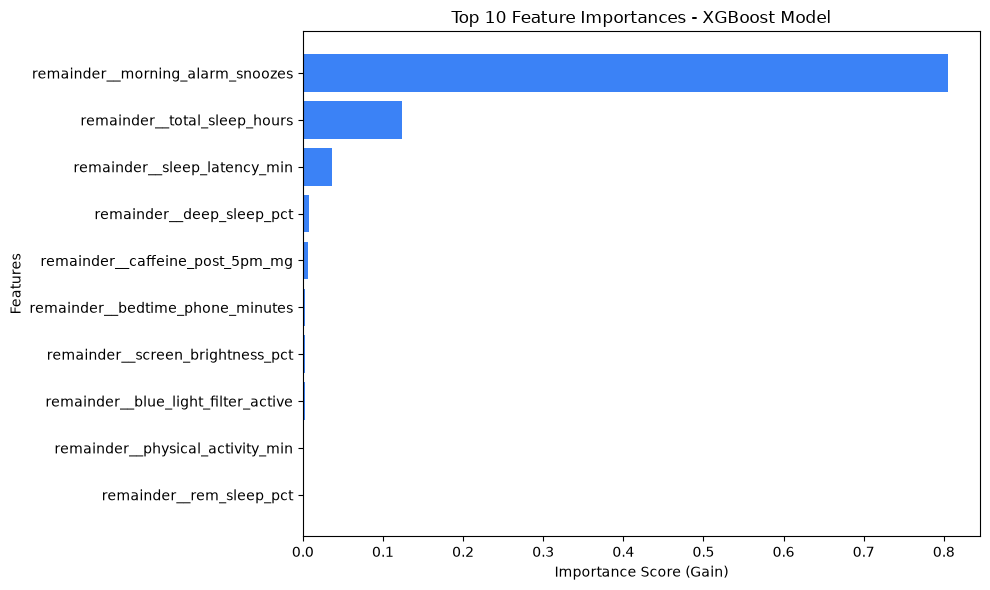

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'].head(10)[::-1], 
         feature_importance_df['Importance'].head(10)[::-1], 
         color='#3b82f6')
plt.xlabel('Importance Score (Gain)')
plt.ylabel('Features')
plt.title('Top 10 Feature Importances - XGBoost Model')
plt.tight_layout()
plt.show()

In [28]:
import joblib
xgb_model = models['xgbr']
joblib.dump(xgb_model, 'xgb_regression_model.pkl')


['xgb_regression_model.pkl']

In [29]:
joblib.dump(ct1, 'column_transformer_regressor.pkl')

['column_transformer_regressor.pkl']